# Remote Salary Premium

**Goal:** Determine whether remote roles pay more or less than on-site roles, and whether this varies by job title or skill.

**Input:** `data_jobs_salary.parquet` (salary subset from `1_data_cleaning.ipynb`)

**What this notebook covers:**
- Overall remote vs on-site salary comparison
- Salary premium/penalty by job title
- Salary premium/penalty by top skills
- Key visualizations and takeaways

---

In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading salary dataset
df_salary = pd.read_parquet('../data/clean/data_jobs_salary.parquet')

df_salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32665 entries, 0 to 32664
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        32665 non-null  object        
 1   job_title              32665 non-null  object        
 2   job_location           32309 non-null  object        
 3   job_via                32657 non-null  object        
 4   job_schedule_type      32665 non-null  object        
 5   job_work_from_home     32665 non-null  bool          
 6   search_location        32665 non-null  object        
 7   job_posted_date        32665 non-null  datetime64[ns]
 8   job_no_degree_mention  32665 non-null  bool          
 9   job_health_insurance   32665 non-null  bool          
 10  job_country            32665 non-null  object        
 11  salary_rate            32665 non-null  object        
 12  salary_year_avg        22003 non-null  float64       
 13  s

## Remote vs On-Site: Overall Salary Comparison

In [2]:
salary_comparison = (
    df_salary.groupby('job_work_from_home')['salary_year_avg']
    .agg(['mean', 'median', 'count'])
    .rename(index={False: 'On-site', True: 'Remote'})
)
salary_comparison

,mean,median,count
job_work_from_home,,,
On-site,121830.018124,115000.000,18724
Remote,131601.899679,128829.625,3279


**Finding**: Remote roles show a clear salary premium over on-site roles — **+$13,830 in median annual salary** (~12% higher). This premium holds even though remote postings represent a much smaller share of the salary-labeled data (3,279 vs 18,724 on-site postings), consistent with the overall ~8.85% remote share found earlier.

In [3]:
role_salary_premium = (
    df_salary.groupby(['job_title_short', 'job_work_from_home'])['salary_year_avg']
    .median()
    .unstack()
    .rename(columns={False: 'onsite_median', True: 'remote_median'})
)
role_salary_premium['premium_pct'] = ((role_salary_premium['remote_median'] - role_salary_premium['onsite_median']) / role_salary_premium['onsite_median']) * 100
role_salary_premium = role_salary_premium.sort_values('premium_pct', ascending=False)
role_salary_premium

job_work_from_home,onsite_median,remote_median,premium_pct
job_title_short,,,
Cloud Engineer,89100.0,140000.0,57.126824
Software Engineer,95000.0,125000.0,31.578947
Machine Learning Engineer,104668.0,127500.0,21.813735
Data Scientist,125000.0,136000.0,8.800000
Business Analyst,85000.0,90000.0,5.882353
Senior Data Scientist,152650.0,160000.0,4.814936
Data Engineer,125000.0,130000.0,4.000000
Senior Data Engineer,147500.0,145000.0,-1.694915
Data Analyst,90000.0,86750.0,-3.611111


In [5]:
role_counts = (
    df_salary.groupby(['job_title_short', 'job_work_from_home'])['salary_year_avg']
    .count()
    .unstack()
    .rename(columns={False: 'onsite_count', True: 'remote_count'})
)
role_salary_premium = role_salary_premium.join(role_counts[['remote_count']])
role_salary_premium

job_work_from_home,onsite_median,remote_median,premium_pct,remote_count
job_title_short,,,,
Cloud Engineer,89100.0,140000.0,57.126824,9
Software Engineer,95000.0,125000.0,31.578947,63
Machine Learning Engineer,104668.0,127500.0,21.813735,40
Data Scientist,125000.0,136000.0,8.800000,949
Business Analyst,85000.0,90000.0,5.882353,77
Senior Data Scientist,152650.0,160000.0,4.814936,337
Data Engineer,125000.0,130000.0,4.000000,751
Senior Data Engineer,147500.0,145000.0,-1.694915,283
Data Analyst,90000.0,86750.0,-3.611111,610


**Finding**: The remote salary premium varies significantly across roles, but sample size matters — some of the largest premiums come from very small remote samples. **Cloud Engineer** (+57%) and **Software Engineer** (+32%) are based on only 9 and 63 remote salary-labeled postings respectively, too small to draw reliable conclusions from.

Looking only at roles with a reasonably sized remote sample (150+ postings), the picture is more modest: **Data Scientist** (+8.8%, n=949) and **Data Engineer** (+4.0%, n=751) show a small positive premium, while **Data Analyst** (-3.6%, n=610) and **Senior Data Analyst** (-5.6%, n=160) show a slight remote penalty. **Senior Data Engineer** is essentially flat (-1.7%, n=283).

**Takeaway**: for Data Analyst/Data Engineer-track roles specifically, remote work does not carry a meaningful salary premium once low-sample roles are excluded — the earlier global premium (+12%) is likely driven by a mix of roles and seniority levels rather than remote status itself.

### Visualizing Remote Salary Premium by Role

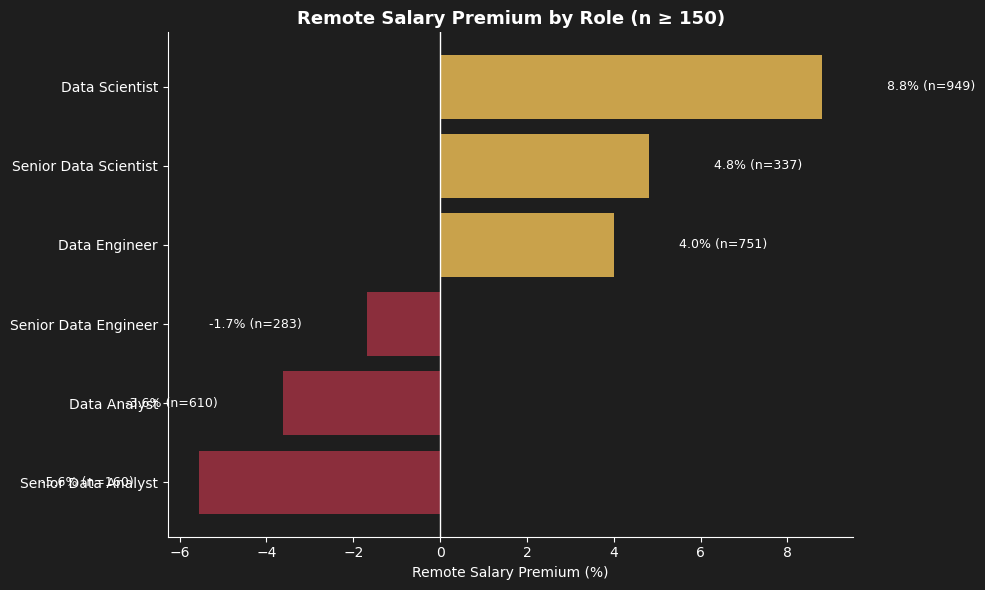

In [6]:
data = role_salary_premium[role_salary_premium['remote_count'] >= 150].reset_index()
data = data.sort_values('premium_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bg_color = '#1e1e1e'
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

colors = ['#8b2e3c' if val < 0 else '#c9a24b' for val in data['premium_pct']]

ax.barh(data['job_title_short'], data['premium_pct'], color=colors)
ax.axvline(0, color='white', linewidth=1)

for i, (val, n) in enumerate(zip(data['premium_pct'], data['remote_count'])):
    label_x = val + (1.5 if val >= 0 else -1.5)
    ha = 'left' if val >= 0 else 'right'
    ax.text(label_x, i, f'{val:.1f}% (n={n})', va='center', ha=ha, color='white', fontsize=9)

ax.set_title('Remote Salary Premium by Role (n ≥ 150)', fontsize=13, weight='bold', color='white')
ax.set_xlabel('Remote Salary Premium (%)', color='white')
ax.set_ylabel('')
ax.tick_params(colors='white')
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('white')

plt.tight_layout()
plt.savefig('../images/remote_salary_premium_by_role.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

## Top Paying Skills for Remote Roles

In [7]:
df_remote_skills = df_salary[
    (df_salary['job_work_from_home'] == True) & 
    (df_salary['job_skills'].notna())
].copy()

df_remote_skills = df_remote_skills.explode('job_skills')

print(f"Remote postings with salary + skills: {df_remote_skills['job_skills'].nunique()} unique skills across {len(df_remote_skills)} rows")

Remote postings with salary + skills: 198 unique skills across 30165 rows


In [8]:
skill_salary = (
    df_remote_skills.groupby('job_skills')['salary_year_avg']
    .agg(['median', 'count'])
    .rename(columns={'median': 'median_salary', 'count': 'postings_count'})
)

# Keep only skills with a reasonably sized sample
skill_salary = skill_salary[skill_salary['postings_count'] >= 50]

top_paying_skills = skill_salary.sort_values('median_salary', ascending=False).head(15)
top_paying_skills

,median_salary,postings_count
job_skills,,
c,157500.0,95
numpy,152500.0,132
ruby,150500.0,56
pytorch,150000.0,193
tensorflow,150000.0,217
matplotlib,150000.0,65
kafka,147500.0,226
scala,147500.0,256
terraform,145000.0,83


**Finding**: Among remote postings with salary data (filtered to skills with at least 50 postings), the highest-paying skills are dominated by **cloud/data engineering tools** (Kubernetes, Terraform, GCP, Airflow, Kafka — all around $145K median) and **machine learning frameworks** (PyTorch, TensorFlow, Scikit-learn — $145K–$150K median). Traditional analyst tools (Excel, Tableau, Power BI) don't appear in this top tier.

**Takeaway**: this reinforces the pattern seen in the role-level analysis — the clearest path to higher-paying remote work isn't just "becoming a Data Engineer" as a title, but specifically building skills in cloud infrastructure, workflow orchestration, and ML frameworks.

### Visualizing Top Paying Remote Skills

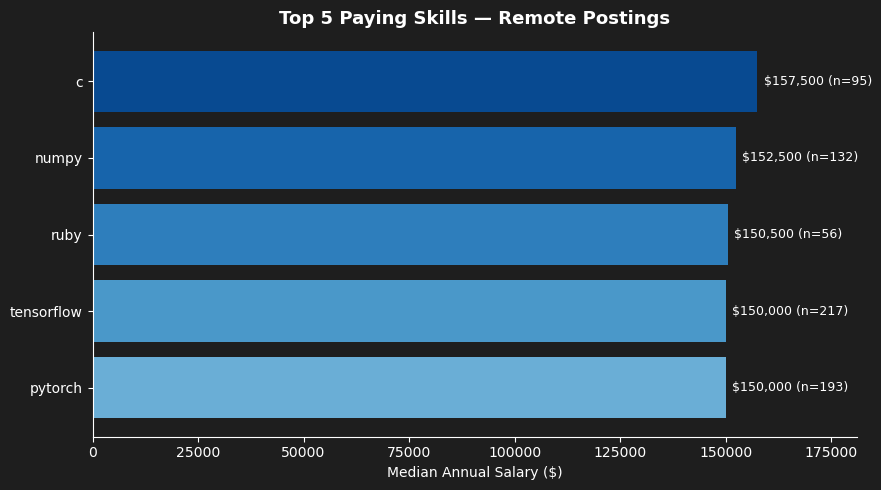

In [10]:
data = top_paying_skills.head(5).reset_index().sort_values('median_salary', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bg_color = '#1e1e1e'
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

colors = sns.color_palette('Blues', n_colors=len(data) + 4)[4:]

ax.barh(data['job_skills'], data['median_salary'], color=colors)

for i, (val, n) in enumerate(zip(data['median_salary'], data['postings_count'])):
    ax.text(val + 1500, i, f'${val:,.0f} (n={n})', va='center', color='white', fontsize=9)

ax.set_title('Top 5 Paying Skills — Remote Postings', fontsize=13, weight='bold', color='white')
ax.set_xlabel('Median Annual Salary ($)', color='white')
ax.set_ylabel('')
ax.tick_params(colors='white')
ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('white')
ax.set_xlim(0, data['median_salary'].max() * 1.15)

plt.tight_layout()
plt.savefig('../images/top_paying_remote_skills.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()

In [14]:
df_category = df_salary[
    (df_salary['job_work_from_home'] == True) & 
    (df_salary['job_type_skills'].notna()) &
    (df_salary['salary_year_avg'].notna())
].copy()

df_category['job_type_skills'] = df_category['job_type_skills'].apply(lambda d: list(d.items()))
df_category = df_category.explode('job_type_skills')
df_category['skill_category'] = df_category['job_type_skills'].apply(lambda x: x[0])

category_counts = df_category['skill_category'].value_counts()
valid_categories = category_counts[category_counts >= 50].index
df_category = df_category[df_category['skill_category'].isin(valid_categories)]

df_category[['skill_category', 'salary_year_avg']].head()

,skill_category,salary_year_avg
4,analyst_tools,120000.0
4,libraries,120000.0
4,databases,120000.0
4,programming,120000.0
4,cloud,120000.0


### Salary Distribution by Skill Category

I also tested whether salaries varied meaningfully across broader skill categories (`programming`, `cloud`, `databases`, `analyst_tools`, `libraries`) rather than individual skills. The distributions turned out to be nearly identical across categories — no meaningful separation in medians or spread — so no chart is included here, as it wouldn't add anything beyond what the numbers already show.

**Finding**: Skill *category* has little to no effect on remote salary. What matters is the specific skill itself — as seen in the previous chart, individual skills like PyTorch or Kubernetes command a clear premium, while their broader category (e.g., "libraries" or "cloud") doesn't predict salary on its own.

## Summary

- Remote roles show a clear overall salary premium: **+$13,830 in median annual salary** (~12% higher) compared to on-site roles.
- This premium is highly uneven across roles once sample size is accounted for. Excluding roles with fewer than 150 remote salary-labeled postings, the picture is modest: **Data Scientist** (+8.8%) and **Data Engineer** (+4.0%) show a small positive premium, while **Data Analyst** (-3.6%) and **Senior Data Analyst** (-5.6%) show a slight remote penalty. **Senior Data Engineer** is essentially flat (-1.7%).
- The global +12% premium is likely driven by a mix of roles and seniority levels rather than remote status itself — for Analyst/Engineer-track roles specifically, remote work does not carry a meaningful salary premium.
- Among individual skills, the highest-paying ones in remote postings are dominated by **cloud/data engineering tools** (Kubernetes, Terraform, GCP, Airflow, Kafka) and **machine learning frameworks** (PyTorch, TensorFlow, Scikit-learn) — all around $145K–$157K median. Traditional analyst tools (Excel, Tableau, Power BI) don't appear in this top tier.
- Broader skill *categories* (e.g., "cloud", "programming", "databases") showed no meaningful salary difference between them — the specific skill matters far more than its category.
- **Takeaway**: the clearest path to higher-paying remote work isn't the job title alone, but specific technical skills — particularly cloud infrastructure, orchestration tools, and ML frameworks.